--- STRESS TEST: DUAL LAYER SYSTEM (Stealth + Robust) ---
Testing 13 livelli di rumore...
[Jitter 1.0ms] -> Stealth: 100% | Robust: 100%
[Jitter 3.0ms] -> Stealth: 100% | Robust: 100%
[Jitter 5.0ms] -> Stealth: 85% | Robust: 100%
[Jitter 7.0ms] -> Stealth: 45% | Robust: 100%
[Jitter 9.0ms] -> Stealth: 10% | Robust: 100%
[Jitter 11.0ms] -> Stealth: 0% | Robust: 100%
[Jitter 13.0ms] -> Stealth: 0% | Robust: 100%
[Jitter 15.0ms] -> Stealth: 0% | Robust: 100%
[Jitter 17.0ms] -> Stealth: 0% | Robust: 90%
[Jitter 19.0ms] -> Stealth: 0% | Robust: 45%
[Jitter 21.0ms] -> Stealth: 0% | Robust: 15%
[Jitter 23.0ms] -> Stealth: 0% | Robust: 0%
[Jitter 25.0ms] -> Stealth: 0% | Robust: 0%


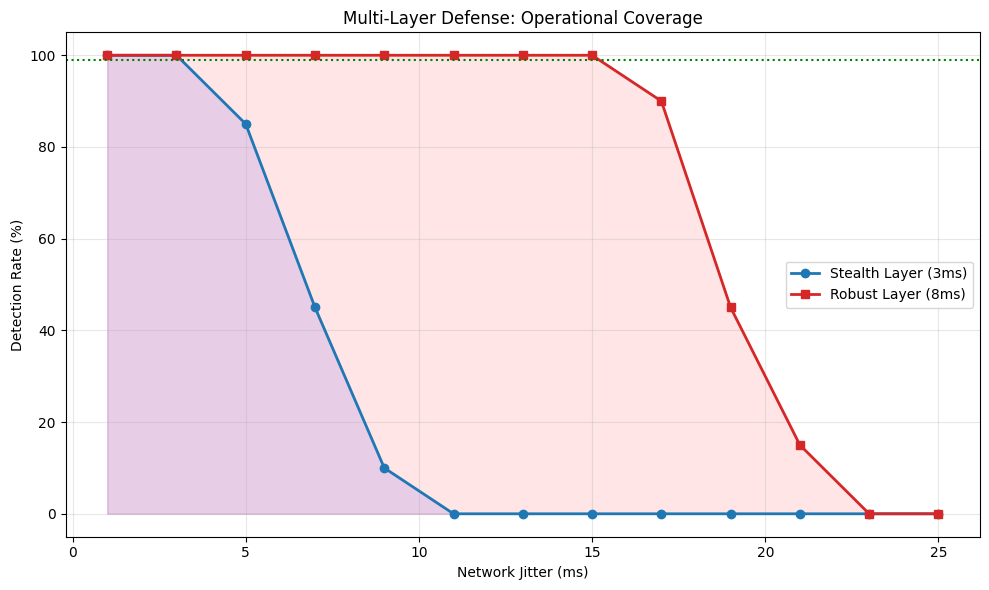

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from dataclasses import dataclass
from typing import List, Tuple, Optional
import random

# --- CONFIGURAZIONE LABORATORIO (DUAL LAYER MODE) ---
CONFIG = {
    'SIMULATION_DURATION': 150,
    'BASE_IAT': 0.02,
    'PN_CODE_LENGTH': 2048,
    'PACKET_LOSS_RATE': 0.0,
    'TRIALS_PER_LEVEL': 20,
    'DECISION_THRESHOLD': 3.0
}

@dataclass
class PacketFlow:
    timestamps: np.ndarray
    sizes: np.ndarray

    @property
    def iats(self) -> np.ndarray:
        """Calcola gli Inter-Arrival Times"""
        return np.diff(self.timestamps)

class TrafficGenerator:
    @staticmethod
    def generate_voip_traffic(duration: int, base_iat: float) -> PacketFlow:
        timestamps = np.arange(0, duration, base_iat)
        source_jitter = np.random.normal(0, 0.0005, size=len(timestamps))
        timestamps += source_jitter
        timestamps = np.sort(timestamps)
        sizes = np.ones(len(timestamps)) * 200
        return PacketFlow(timestamps, sizes)

class ProxyNetworkChannel:
    def __init__(self, jitter_std: float, loss_rate: float):
        self.jitter_std = jitter_std
        self.loss_rate = loss_rate

    def traverse(self, flow: PacketFlow) -> PacketFlow:
        mask = np.random.rand(len(flow.timestamps)) > self.loss_rate
        kept_timestamps = flow.timestamps[mask]
        kept_sizes = flow.sizes[mask]
        noise = np.random.normal(0, self.jitter_std, size=kept_timestamps.shape)
        noisy_timestamps = kept_timestamps + noise
        noisy_timestamps = np.sort(noisy_timestamps)
        noisy_timestamps = noisy_timestamps - noisy_timestamps[0]
        return PacketFlow(noisy_timestamps, kept_sizes)

class MultiLayerWatermarker:
    """Gestisce livelli multipli di watermark (CDMA)"""
    def __init__(self, code_length: int):
        self.code_length = code_length
        self.layers = []

    def add_layer(self, name: str, strength: float):
        key = np.random.choice([-1, 1], size=self.code_length)
        self.layers.append({'name': name, 'strength': strength, 'key': key})

    def encode(self, flow: PacketFlow) -> PacketFlow:
        iats = flow.iats
        new_iats = iats.copy()
        start_idx = len(iats) // 3
        end_idx = start_idx + self.code_length

        if end_idx > len(iats):
             return flow

        segment = new_iats[start_idx:end_idx]

        # Sovrapposizione dei segnali (CDMA)
        total_modulation = np.zeros_like(segment)
        for layer in self.layers:
            total_modulation += (layer['key'] * layer['strength'])

        modulated = segment + total_modulation
        modulated = np.maximum(modulated, 0.0001)
        new_iats[start_idx:end_idx] = modulated
        new_timestamps = np.concatenate(([0], np.cumsum(new_iats)))
        return PacketFlow(new_timestamps, flow.sizes)

class ForensicAnalyzer:
    @staticmethod
    def correlate(flow: PacketFlow, key: np.ndarray) -> float:
        signal_trace = flow.iats
        signal_norm = (signal_trace - np.mean(signal_trace)) / (np.std(signal_trace) + 1e-10)
        key_norm = (key - np.mean(key)) / (np.std(key) + 1e-10)
        corr = np.correlate(signal_norm, key_norm, mode='valid')
        corr /= len(key)
        return np.max(np.abs(corr))

def run_dual_trial(jitter_val):
    np.random.seed(None)
    attacker = TrafficGenerator()
    network = ProxyNetworkChannel(jitter_std=jitter_val, loss_rate=CONFIG['PACKET_LOSS_RATE'])

    # DEFINIZIONE DUAL LAYER
    defender = MultiLayerWatermarker(code_length=CONFIG['PN_CODE_LENGTH'])
    defender.add_layer("Stealth", 0.003)  # 3ms (Low Jitter)
    defender.add_layer("Robust", 0.008)   # 8ms (High Jitter)

    raw_flow = attacker.generate_voip_traffic(CONFIG['SIMULATION_DURATION'], CONFIG['BASE_IAT'])
    marked_flow = defender.encode(raw_flow)
    captured_flow = network.traverse(marked_flow)

    # Analisi Parallela
    score_stealth = ForensicAnalyzer.correlate(captured_flow, defender.layers[0]['key'])
    score_robust = ForensicAnalyzer.correlate(captured_flow, defender.layers[1]['key'])

    # Controllo Noise Floor
    wrong_key = np.random.choice([-1, 1], size=CONFIG['PN_CODE_LENGTH'])
    score_wrong = ForensicAnalyzer.correlate(captured_flow, wrong_key)

    return score_stealth, score_robust, score_wrong

def run_stress_test():
    print(f"--- STRESS TEST: DUAL LAYER SYSTEM (Stealth + Robust) ---")
    # Test esteso fino a 25ms
    jitter_levels = np.arange(0.001, 0.026, 0.002)

    rel_stealth = []
    rel_robust = []

    print(f"Testing {len(jitter_levels)} livelli di rumore...")

    for jitter in jitter_levels:
        success_s = 0
        success_r = 0
        print(f"[Jitter {jitter*1000:.1f}ms] ", end="")

        for _ in range(CONFIG['TRIALS_PER_LEVEL']):
            s, r, w = run_dual_trial(jitter)

            snr_s = s / (w + 1e-10)
            snr_r = r / (w + 1e-10)

            if snr_s > CONFIG['DECISION_THRESHOLD']:
                success_s += 1
            if snr_r > CONFIG['DECISION_THRESHOLD']:
                success_r += 1

        rs = (success_s / CONFIG['TRIALS_PER_LEVEL']) * 100
        rr = (success_r / CONFIG['TRIALS_PER_LEVEL']) * 100
        rel_stealth.append(rs)
        rel_robust.append(rr)

        print(f"-> Stealth: {rs:.0f}% | Robust: {rr:.0f}%")

    visualize_dual_layer(jitter_levels, rel_stealth, rel_robust)

def visualize_dual_layer(jitters, r_stealth, r_robust):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(jitters * 1000, r_stealth, color='tab:blue', marker='o', linewidth=2, label='Stealth Layer (3ms)')
    ax.plot(jitters * 1000, r_robust, color='tab:red', marker='s', linewidth=2, label='Robust Layer (8ms)')

    # Area di overlapping
    ax.fill_between(jitters * 1000, r_stealth, alpha=0.1, color='blue')
    ax.fill_between(jitters * 1000, r_robust, alpha=0.1, color='red')

    ax.set_xlabel('Network Jitter (ms)')
    ax.set_ylabel('Detection Rate (%)')
    ax.set_title("Multi-Layer Defense: Operational Coverage")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 105)
    ax.legend()

    # Annotazioni
    ax.axhline(99, color='green', linestyle=':', label='99% Zone')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_stress_test()